# Decision Tree

A decision tree is a type of supervised learning algorithm that is commonly used in machine learning to model and predict outcomes based on input data. It is a tree-like structure where each internal node tests on attribute, each branch corresponds to attribute value and each leaf node represents the final decision or prediction. The decision tree algorithm falls under the category of supervised learning. They can be used to solve both regression and classification problems.Decision tree learning is one of the most widely adopted algorithms for classification.

**Decision Tree Terminologies**

There are specialized terms associated with decision trees that denote various components and facets of the tree structure and decision-making procedure. :

**Root Node:** 

A decision tree’s root node, which represents the original choice or feature from which the tree branches, is the highest node.

**Internal Nodes (Decision Nodes):** 

Nodes in the tree whose choices are determined by the values of particular attributes. There are branches on these nodes that go to other nodes.

**Leaf Nodes (Terminal Nodes):**

The branches’ termini, when choices or forecasts are decided upon. There are no more branches on leaf nodes.

**Branches (Edges):** 

Links between nodes that show how decisions are made in response to particular circumstances.
Splitting: The process of dividing a node into two or more sub-nodes based on a decision criterion. It involves selecting a feature and a threshold to create subsets of data.

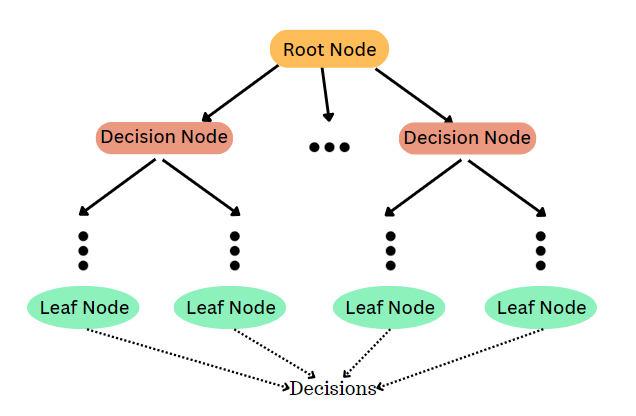

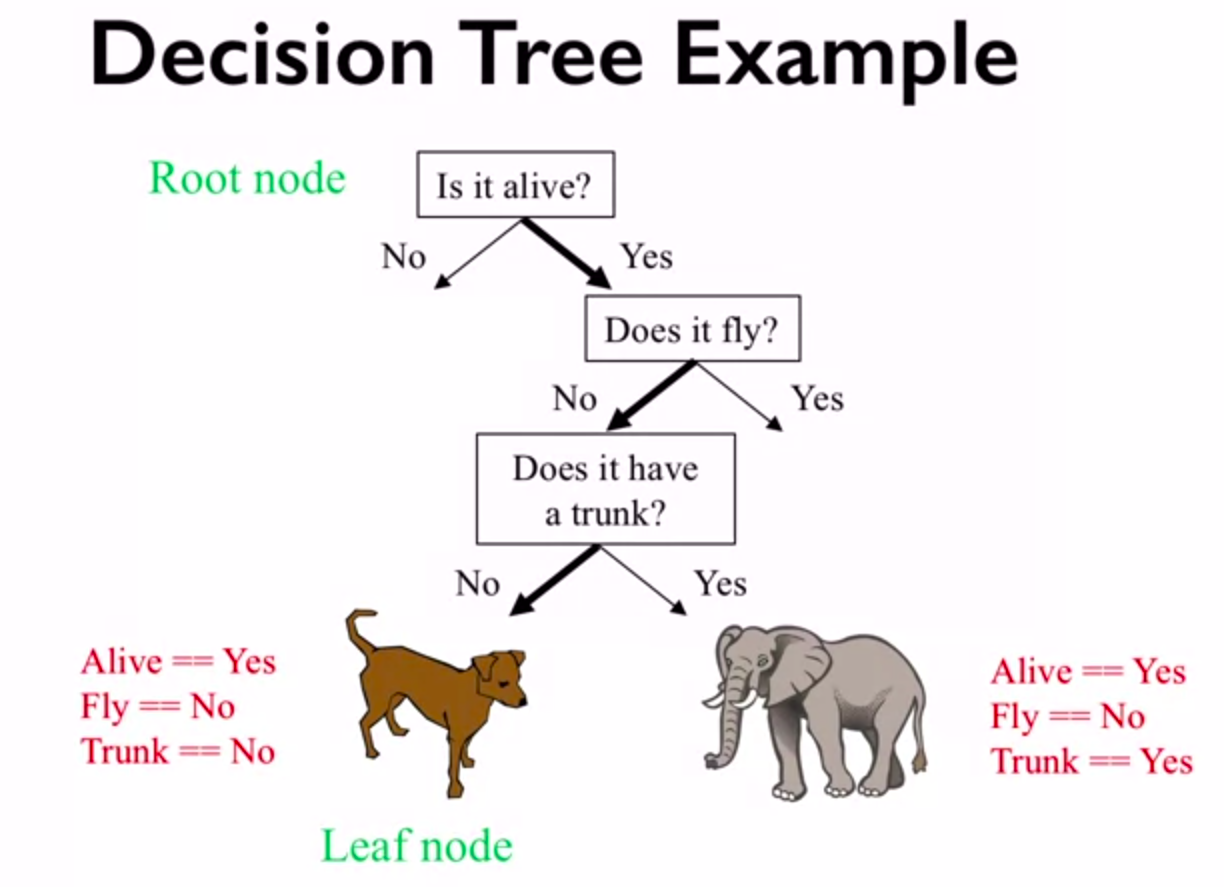

### Information Gain:

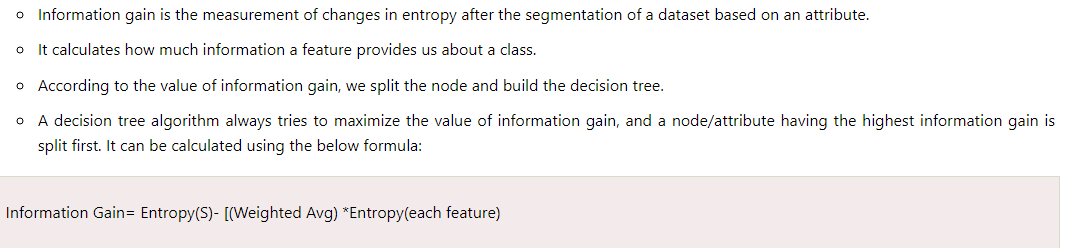

#### Entropy: 

Entropy is a metric to measure the impurity in a given attribute. It specifies randomness in data. Entropy can be calculated as:

**Entropy(s)= -P(yes)log2 P(yes)- P(no) log2 P(no)**

**Where,**

**S= Total number of samples**

**P(yes)= probability of yes**

**P(no)= probability of no**

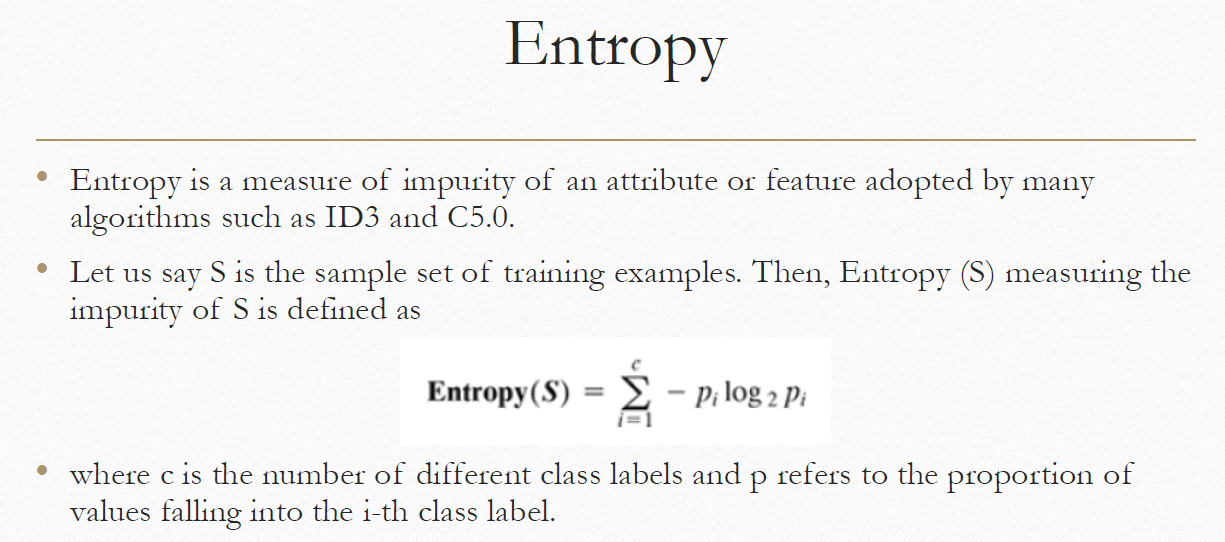

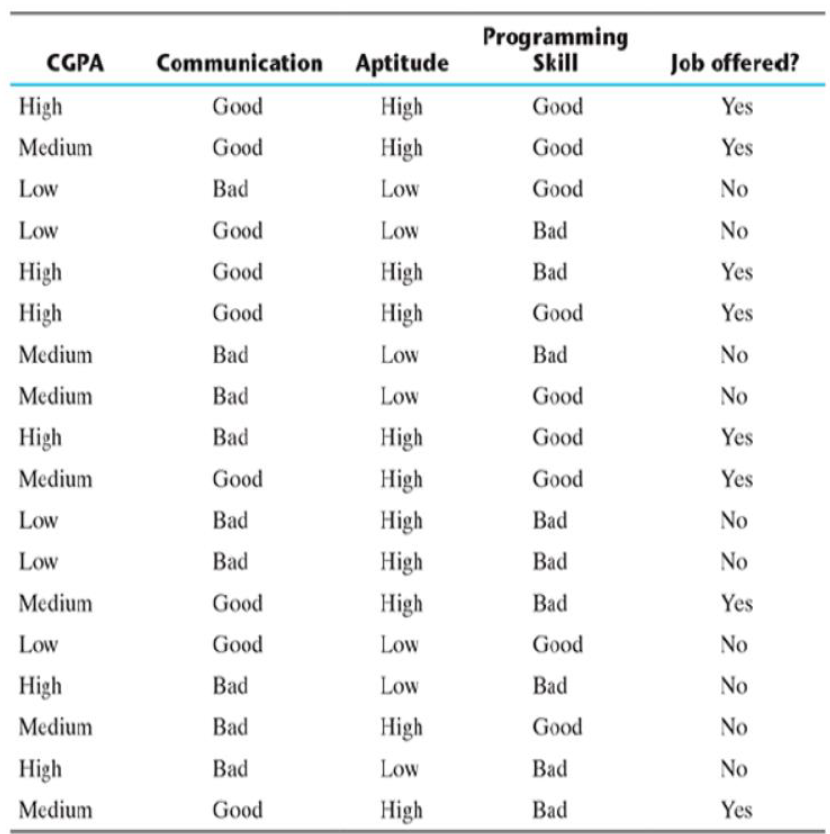

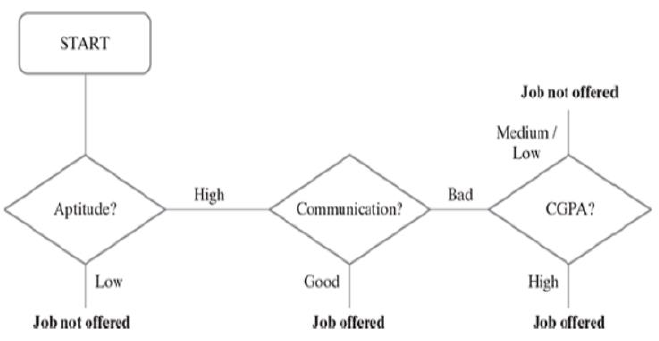

There are many implementations of decision tree, the most prominent ones being C5.0, CART (Classification and Regression Tree), CHAID (Chi-square Automatic Interaction Detector) and ID3 (Iterative Dichotomiser3) algorithms.

The biggest challenge of a decision tree algorithm is to find out which feature to split upon.

The main driver for identifying the feature is that the data should be split in such a way that the partitions created by the split should contain examples belonging to a single class. If that happens, the partitions are considered to be pure.

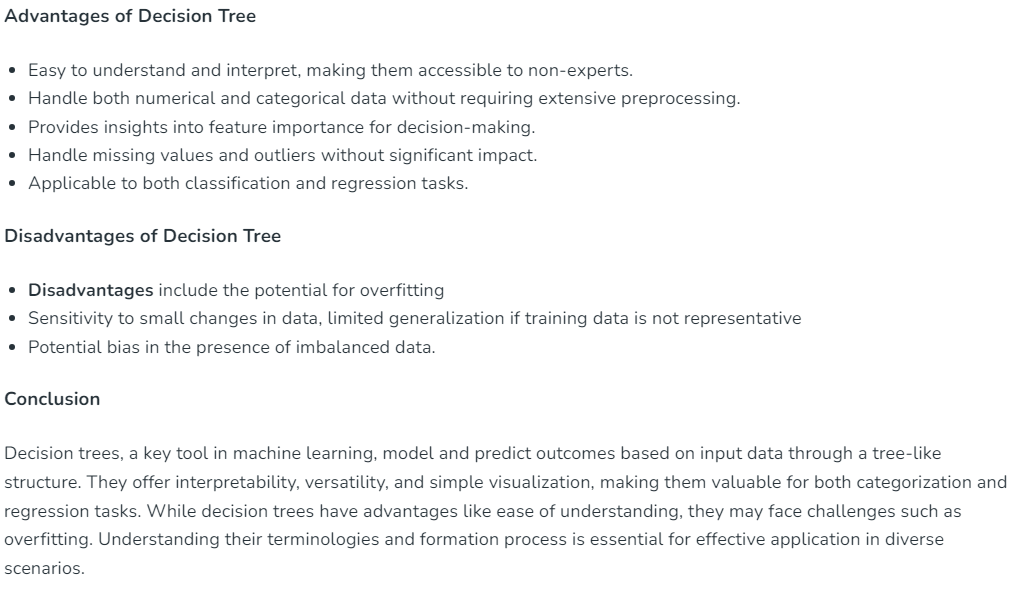

## Model-1 DecisionTeeDataset - Num.csv (Job Offered)

In [1]:
import pandas as pd
data = pd.read_csv('DecisionTreeDataset -Num.csv')
data

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [2]:
x = data.drop('Job Offered', axis = 1)
y = data['Job Offered']

In [3]:
x.shape

(18, 4)

In [4]:
y.shape

(18,)

In [5]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy = DecisionTreeClassifier(criterion = 'entropy')
model = dtree_entropy.fit(x,y)

In [6]:
dtree_entropy.get_depth()

3

In [7]:
from sklearn import tree
text_representation = tree.export_text(dtree_entropy,feature_names=['CGPA','Communication','Apptitude','Programming Skill'])
print(text_representation)

|--- Apptitude <= 0.50
|   |--- class: 0
|--- Apptitude >  0.50
|   |--- Communication <= 0.50
|   |   |--- CGPA <= 1.50
|   |   |   |--- class: 0
|   |   |--- CGPA >  1.50
|   |   |   |--- class: 1
|   |--- Communication >  0.50
|   |   |--- class: 1



In [8]:
#Predictions
prediction = model.predict(x)
prediction

array([1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1])

In [9]:
diff=pd.DataFrame({'Actual':y,'Predicted':prediction})
diff

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,1,1
5,1,1
6,0,0
7,0,0
8,1,1
9,1,1


In [10]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, prediction)
cm

array([[10,  0],
       [ 0,  8]])

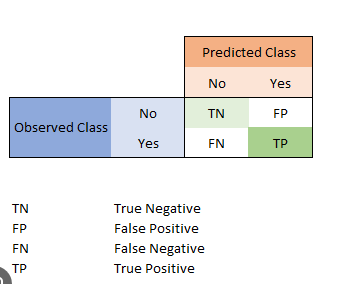

In [11]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print(TP, FN, TN, FP)

8 0 10 0


In [17]:
accuracy = (TP + TN) / (TP + FP + FN + TN)
print(accuracy)

1.0


In [18]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y, prediction))

1.0


In [19]:
sensitivity = TP / (TP + FN)
print(sensitivity)

1.0


In [20]:
specificity = TN / (TN+FP)
print(specificity)

1.0


In [21]:
data.head(1)

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1


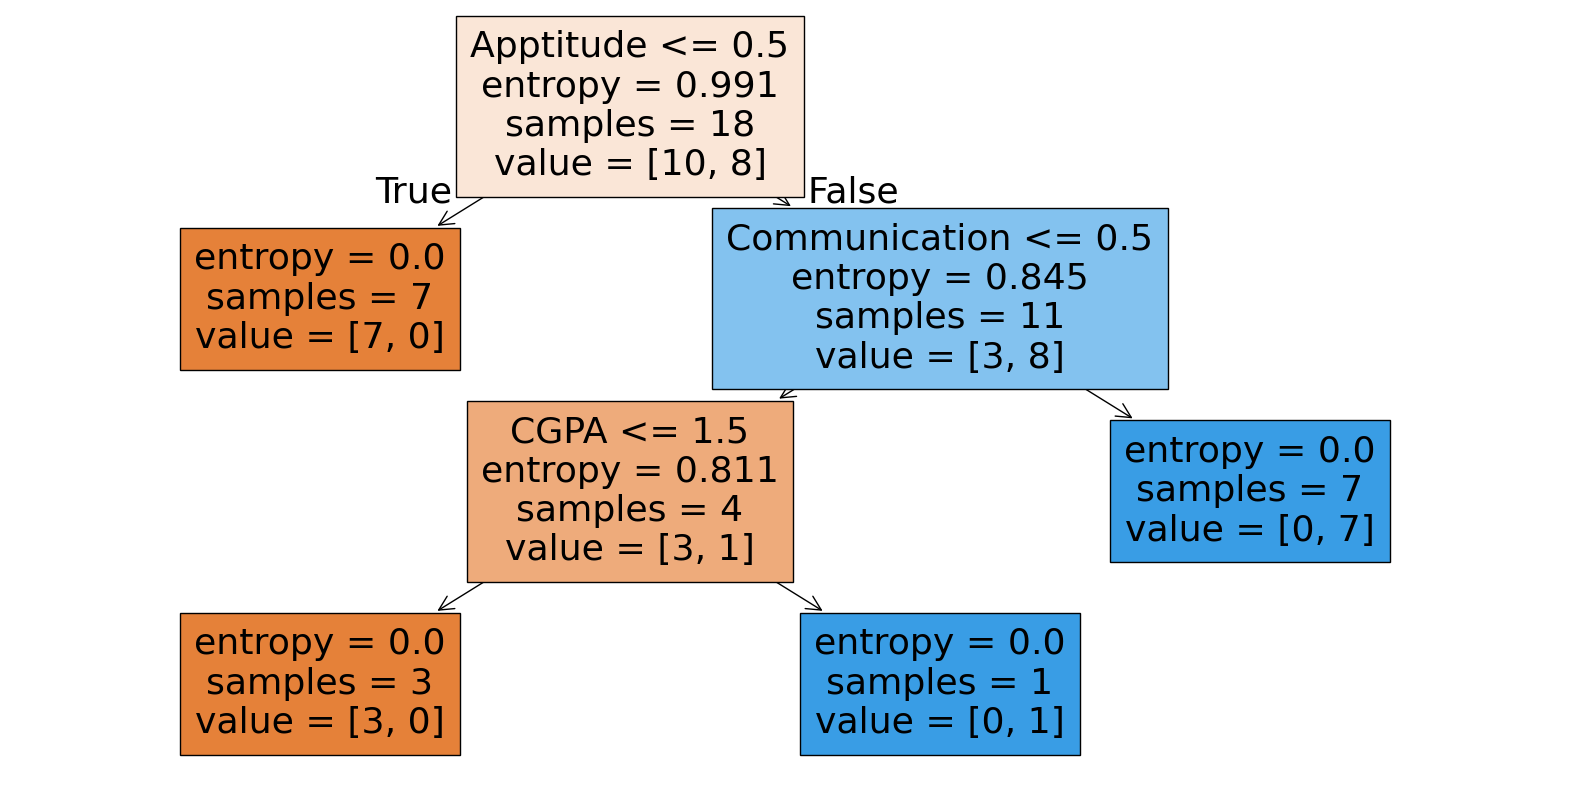

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree_entropy, feature_names=['CGPA','Communication','Apptitude','Programming Skill'],  filled=True)
plt.show()

## Model-2 Diabetes.csv

In [23]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [24]:
x = df.drop('Outcome', axis = 1)
y = df['Outcome']

In [25]:
x.shape

(768, 8)

In [26]:
y.shape

(768,)

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(614, 8)
(154, 8)
(614,)
(154,)


In [31]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy = DecisionTreeClassifier(criterion = 'entropy')
model = dtree_entropy.fit(x_train,y_train)
dtree_entropy.get_depth()

16

In [30]:
# we can change the depth of tree by max_depth parameter
from sklearn.tree import DecisionTreeClassifier
dtree_entropy = DecisionTreeClassifier(criterion = 'entropy',max_depth=5) 
model = dtree_entropy.fit(x_train,y_train)
dtree_entropy.get_depth()

5

In [32]:
feature=list(x.columns)
feature

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [33]:
from sklearn import tree
text_representation = tree.export_text(dtree_entropy,feature_names=feature)
print(text_representation)

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 30.95
|   |   |   |--- DiabetesPedigreeFunction <= 0.67
|   |   |   |   |--- class: 0
|   |   |   |--- DiabetesPedigreeFunction >  0.67
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.69
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- DiabetesPedigreeFunction >  0.69
|   |   |   |   |   |--- class: 0
|   |   |--- BMI >  30.95
|   |   |   |--- BloodPressure <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- BloodPressure >  37.00
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.50
|   |   |   |   |   |--- SkinThickness <= 8.50
|   |   |   |   |   |   |--- Glucose <= 109.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Glucose >  109.50
|   |   |   |   |   |   |   |--- BMI <= 32.45
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- BMI >  32.45
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- SkinThickness >  8.50
|   |   |   |   |  

In [34]:
#Predictions
y_pred = dtree_entropy.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0])

In [35]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

,Actual,Predicted
668,0,0
324,0,0
624,0,0
690,0,0
473,0,0
...,...,...
355,1,1
534,0,0
344,0,1
296,1,1


In [36]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[74, 25],
       [19, 36]])

In [37]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print(TP, FN, TN, FP)

36 19 74 25


In [38]:
accuracy = (TP + TN) / (TP + FP + FN + TN)
accuracy

np.float64(0.7142857142857143)

In [39]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7142857142857143

In [42]:
sensitivity = TP / (TP + FN)
print(sensitivity)

0.6545454545454545


In [44]:
from sklearn.metrics import recall_score
print('Sensitivity:',recall_score(y_test,y_pred))

Sensitivity: 0.6545454545454545


In [43]:
specificity=TN/(TN+FP)
print(specificity)

0.7474747474747475


In [45]:
from sklearn.metrics import recall_score
print('Specificity:',recall_score(y_test,y_pred,pos_label=0))

Specificity: 0.7474747474747475


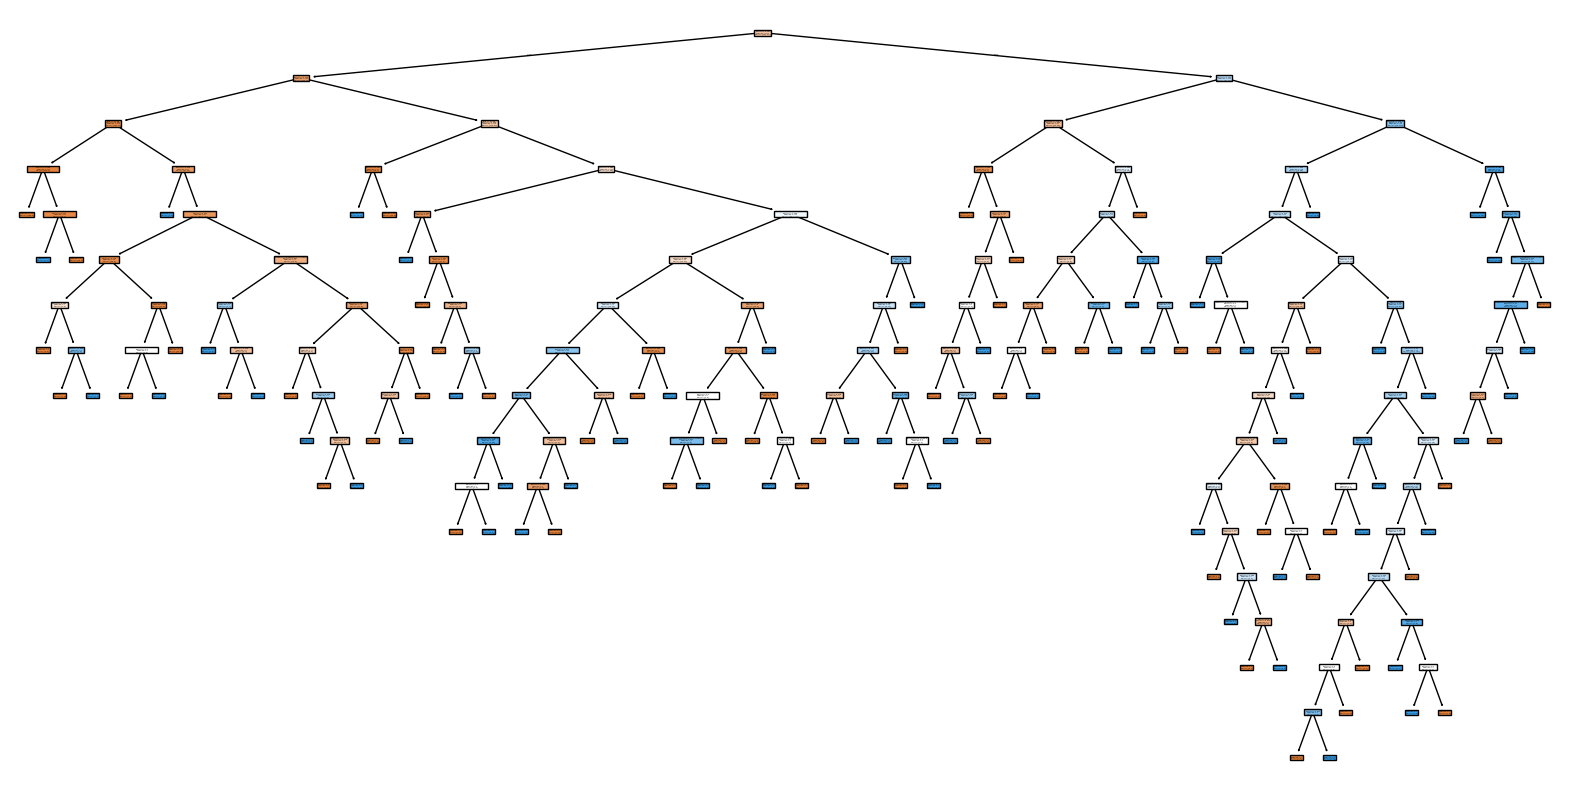

In [46]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree_entropy, feature_names=feature,  filled=True)
plt.show()

## Model-3 DecisionTree_Sports.csv (Play_Sports?)

In [47]:
import pandas as pd
df=pd.read_csv('DecisionTree_Sports.csv')
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [48]:
import numpy as np
df['Weather']=np.where(df['Weather']=='Sunny',2,(np.where(df['Weather']=='Cloudy',1,0)))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,Hot,High,Weak,No
1,Day 2,2,Hot,High,Strong,No
2,Day 3,1,Hot,High,Weak,Yes
3,Day 4,0,Mild,High,Weak,Yes
4,Day 5,0,Cool,Normal,Weak,Yes
5,Day 6,0,Cool,Normal,Strong,No
6,Day 7,1,Cool,Normal,Strong,Yes
7,Day 8,2,Mild,High,Weak,No
8,Day 9,2,Cool,Normal,Weak,Yes
9,Day 10,0,Mild,Normal,Weak,Yes


In [49]:
df['Temperature']=np.where(df['Temperature']=='Hot',2,(np.where(df['Temperature']=='Mild',1,0)))
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,2,High,Weak,No
1,Day 2,2,2,High,Strong,No
2,Day 3,1,2,High,Weak,Yes
3,Day 4,0,1,High,Weak,Yes
4,Day 5,0,0,Normal,Weak,Yes
5,Day 6,0,0,Normal,Strong,No
6,Day 7,1,0,Normal,Strong,Yes
7,Day 8,2,1,High,Weak,No
8,Day 9,2,0,Normal,Weak,Yes
9,Day 10,0,1,Normal,Weak,Yes


In [50]:
df['Humidity']=np.where(df['Humidity']=='High',1,0)
df['Wind']=np.where(df['Wind']=='Weak',0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,2,1,0,No
1,Day 2,2,2,1,1,No
2,Day 3,1,2,1,0,Yes
3,Day 4,0,1,1,0,Yes
4,Day 5,0,0,0,0,Yes
5,Day 6,0,0,0,1,No
6,Day 7,1,0,0,1,Yes
7,Day 8,2,1,1,0,No
8,Day 9,2,0,0,0,Yes
9,Day 10,0,1,0,0,Yes


In [51]:
x=df.iloc[:,1:5]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)



(14, 4)
(14,)


In [52]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy = DecisionTreeClassifier(criterion = 'entropy')
model = dtree_entropy.fit(x, y)

In [53]:
dtree_entropy.get_depth()

4

In [54]:
from sklearn import tree
text_representation = tree.export_text(dtree_entropy,feature_names=['Weather', 'Temperature', 'Humidity', 'Wind'])
print(text_representation)

|--- Humidity <= 0.50
|   |--- Weather <= 0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- class: Yes
|   |   |--- Wind >  0.50
|   |   |   |--- class: No
|   |--- Weather >  0.50
|   |   |--- class: Yes
|--- Humidity >  0.50
|   |--- Weather <= 1.50
|   |   |--- Weather <= 0.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: No
|   |   |--- Weather >  0.50
|   |   |   |--- class: Yes
|   |--- Weather >  1.50
|   |   |--- class: No



In [55]:
#Predictions
prediction = dtree_entropy.predict(x)
prediction

array(['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No'], dtype=object)

In [56]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, prediction)
cm

array([[5, 0],
       [0, 9]])

In [57]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print(TP, FN, TN, FP)

9 0 5 0


In [58]:
from sklearn.metrics import accuracy_score
accuracy_score(y, prediction)

1.0

In [59]:
feature=list(x.columns)
feature

['Weather', 'Temperature', 'Humidity', 'Wind']

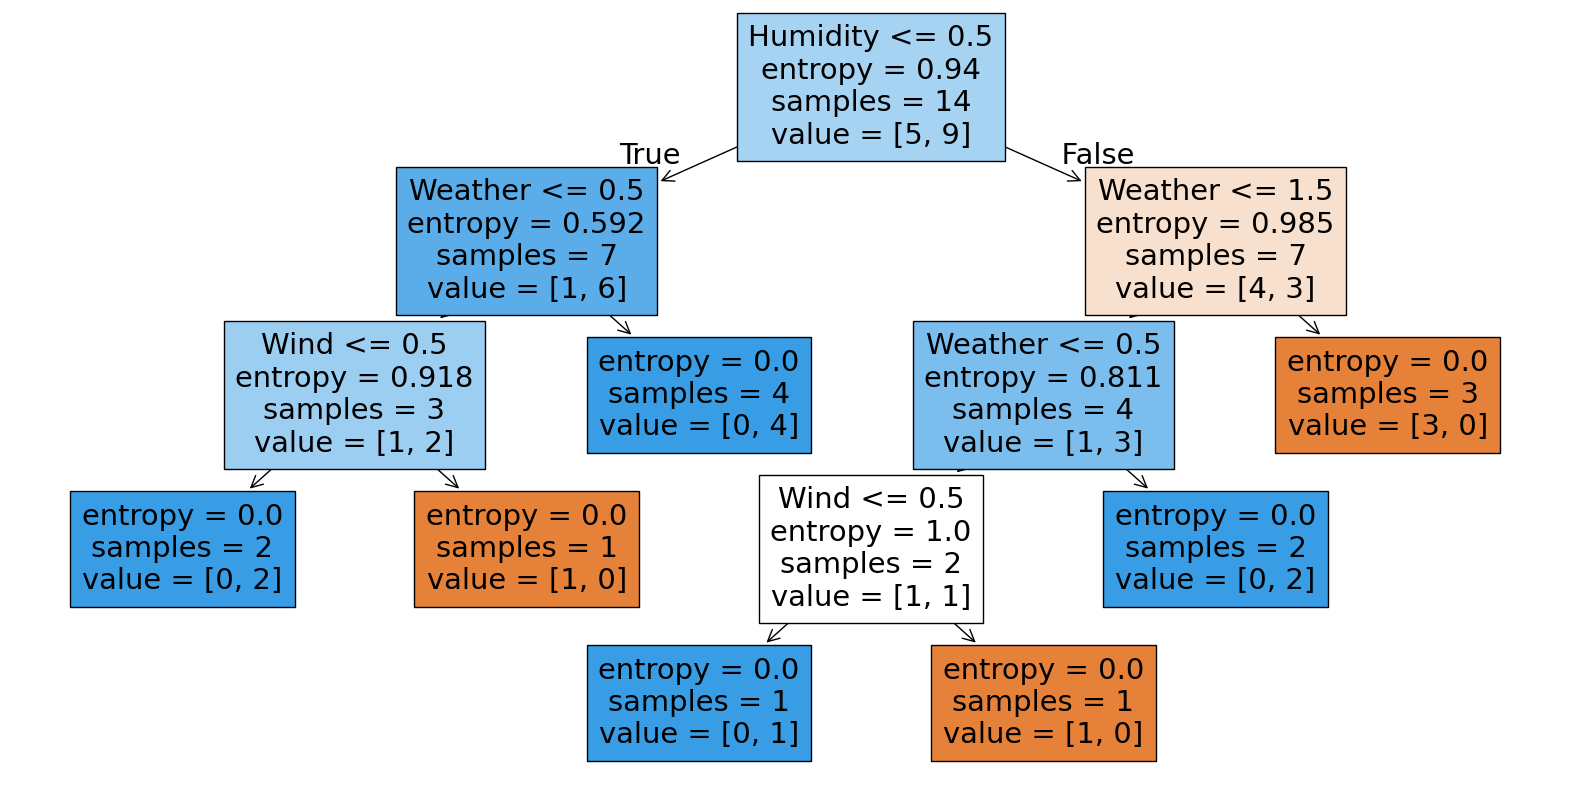

In [60]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dtree_entropy, feature_names=feature , filled=True)
plt.show()

## Model-4 Social_Network_Ads.csv

In [61]:
import pandas as pd
df=pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [62]:
import numpy as np
df['Gender']=np.where(df['Gender']=='Female',0,1)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0
...,...,...,...,...,...
395,15691863,0,46,41000,1
396,15706071,1,51,23000,1
397,15654296,0,50,20000,1
398,15755018,1,36,33000,0


In [63]:
x=df.iloc[:,1:4]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(400, 3)
(400,)


In [64]:
x.columns

Index(['Gender', 'Age', 'EstimatedSalary'], dtype='object')

In [65]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(320, 3)
(80, 3)
(320,)
(80,)


In [67]:
from sklearn.tree import DecisionTreeClassifier
dtree_entropy = DecisionTreeClassifier(criterion = 'entropy',random_state=1)
model = dtree_entropy.fit(x_train, y_train)

In [68]:
model.get_depth()

15

In [69]:
from sklearn import tree
text_representation = tree.export_text(dtree_entropy,feature_names=list(x.columns))
print(text_representation)

|--- Age <= 44.50
|   |--- EstimatedSalary <= 90500.00
|   |   |--- Age <= 36.50
|   |   |   |--- class: 0
|   |   |--- Age >  36.50
|   |   |   |--- EstimatedSalary <= 67500.00
|   |   |   |   |--- class: 0
|   |   |   |--- EstimatedSalary >  67500.00
|   |   |   |   |--- EstimatedSalary <= 83500.00
|   |   |   |   |   |--- Age <= 41.50
|   |   |   |   |   |   |--- EstimatedSalary <= 70500.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- EstimatedSalary >  70500.00
|   |   |   |   |   |   |   |--- Age <= 40.50
|   |   |   |   |   |   |   |   |--- EstimatedSalary <= 79500.00
|   |   |   |   |   |   |   |   |   |--- EstimatedSalary <= 78500.00
|   |   |   |   |   |   |   |   |   |   |--- Age <= 38.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |   |--- Age >  38.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |--- EstimatedSalary >  78500.00
|   

In [70]:
#Predictions
y_pred = model.predict(x_test)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [71]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

,Actual,Predicted
209,0,1
280,1,1
33,0,0
210,1,0
93,0,0
...,...,...
246,0,0
227,1,1
369,1,1
176,0,0


In [72]:
#Metric Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[46,  6],
       [ 6, 22]])

In [75]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]
print(TN, FP, FN, TP)

46 6 6 22


In [83]:
accuracy = (TP + TN) / (TP + FP + FN + TN)
print(accuracy)

0.85


In [77]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.85

In [84]:
sensitivity = TP / (TP + FN)
print(sensitivity)

0.7857142857142857


In [80]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,y_pred))

Sensitivity: 0.7857142857142857


In [85]:
specificity=TN/(TN+FP)
print(specificity)

0.8846153846153846


In [82]:
from sklearn.metrics import recall_score
print("Specificity:",recall_score(y_test,y_pred,pos_label=0))

Specificity: 0.8846153846153846


In [86]:
feature=list(x.columns)
feature

['Gender', 'Age', 'EstimatedSalary']

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20))
plot_tree(dtree_entropy, feature_names=feature,  filled=True)
plt.show()